In [23]:
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, GRU, LSTM, Dropout


In [24]:
def MinMaxScaler(data):
    numerator = data - np.min(data, 0)
    denominator = np.max(data, 0) - np.min(data, 0)
    return numerator / (denominator + 1e-7)


df = fdr.DataReader('005930', '2018-05-04', '2020-01-22')
dfx = df[['Open', 'High', 'Low', 'Volume', 'Close']]
dfx = MinMaxScaler(dfx)
dfy = dfx[['Close']]
dfx = dfx[['Open', 'High', 'Low', 'Volume']]

In [25]:
x = dfx.values.tolist()
y = dfy.values.tolist()

window_size = 10
data_x = []
data_y = []
for i in range(len(y) - window_size):
    _x = x[i: i + window_size]
    _y = y[i + window_size]
    data_x.append(_x)
    data_y.append(_y)

In [26]:
train_size = int(len(data_y) * 0.7)
val_size = int(len(data_y) * 0.2)
train_x = np.array(data_x[0 : train_size])
train_y = np.array(data_y[0 : train_size])
val_x = np.array(data_x[train_size:train_size+val_size])
val_y = np.array(data_y[train_size:train_size+val_size])
test_size = len(data_y) - train_size - val_size
test_x = np.array(data_x[train_size+val_size: len(data_x)])
test_y = np.array(data_y[train_size+val_size: len(data_y)])
print('훈련 데이터 크기:', train_x.shape, train_y.shape)
print('검증 데이터 크기:', val_x.shape, val_y.shape)
print('테스트 데이터 크기:', test_x.shape, test_y.shape)

훈련 데이터 크기: (287, 10, 4) (287, 1)
검증 데이터 크기: (82, 10, 4) (82, 1)
테스트 데이터 크기: (42, 10, 4) (42, 1)


In [27]:
# RNN
model_RNN = Sequential()
model_RNN.add(SimpleRNN(units=20, activation='tanh', return_sequences=True, input_shape=(10,4)))
model_RNN.add(Dropout(0.1))
model_RNN.add(SimpleRNN(units=20, activation='tanh'))
model_RNN.add(Dropout(0.1))
model_RNN.add(Dense(units=1))
model_RNN.summary()

model_RNN.compile(optimizer='adam', loss='mean_squared_error')
history_RNN = model_RNN.fit(train_x, train_y, validation_data=(val_x, val_y), epochs=70, batch_size=30)

/home/js/LLM/intro/intro_venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 10, 20)         │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.1793 - val_loss: 0.0884
Epoch 2/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2235 - val_loss: 0.0460
Epoch 3/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0979 - val_loss: 0.0859
Epoch 4/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1165 - val_loss: 0.0437
Epoch 5/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0858 - val_loss: 0.0340
Epoch 6/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0791 - val_loss: 0.0394
Epoch 7/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0672 - val_loss: 0.0330
Epoch 8/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0696 - val_loss: 0.0343
Epoch 9/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0573 - val_loss: 0.0275
Epoch 10/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0535 - val_loss: 0.0219
Epoch 11/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0488 - val_loss: 0.0167
Epoch 12/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0347 - val_l

In [28]:
# GRU
model_GRU = Sequential()
model_GRU.add(GRU(units=20, activation='tanh', return_sequences=True, input_shape=(10,4)))
model_GRU.add(Dropout(0.1))
model_GRU.add(GRU(units=20, activation='tanh'))
model_GRU.add(Dropout(0.1))
model_GRU.add(Dense(units=1))
model_GRU.summary()

model_GRU.compile(optimizer='adam', loss='mean_squared_error')
history_GRU = model_GRU.fit(train_x, train_y, validation_data=(val_x, val_y), epochs=70, batch_size=30)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 10, 20)         │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 20)             │         2,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,101 (16.02 KB)

 Trainable params: 4,101 (16.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1922 - val_loss: 0.0850
Epoch 2/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0231 - val_loss: 0.0067
Epoch 3/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0144 - val_loss: 0.0060
Epoch 4/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096 - val_loss: 0.0129
Epoch 5/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0070 - val_loss: 0.0167
Epoch 6/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0077 - val_loss: 0.0103
Epoch 7/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0056 - val_loss: 0.0072
Epoch 8/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0060 - val_loss: 0.0077
Epoch 9/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0066 - val_loss: 0.0073
Epoch 10/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - val_loss: 0.0069
Epoch 11/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0049 - val_loss: 0.0057
Epoch 12/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - val_l

In [29]:
# LSTM
model_LSTM = Sequential()
model_LSTM.add(LSTM(units=20, activation='tanh', return_sequences=True, input_shape=(10,4)))
model_LSTM.add(Dropout(0.1))
model_LSTM.add(LSTM(units=20, activation='tanh'))
model_LSTM.add(Dropout(0.1))
model_LSTM.add(Dense(units=1))
model_LSTM.summary()

model_LSTM.compile(optimizer='adam', loss='mean_squared_error')
history_LSTM = model_LSTM.fit(train_x, train_y, validation_data=(val_x, val_y), epochs=70, batch_size=30)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10, 20)         │         2,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 20)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0960 - val_loss: 0.0629
Epoch 2/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0166 - val_loss: 0.0051
Epoch 3/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0095 - val_loss: 0.0070
Epoch 4/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054 - val_loss: 0.0163
Epoch 5/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - val_loss: 0.0103
Epoch 6/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - val_loss: 0.0072
Epoch 7/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 - val_loss: 0.0088
Epoch 8/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 - val_loss: 0.0081
Epoch 9/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - val_loss: 0.0072
Epoch 10/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0044 - val_loss: 0.0068
Epoch 11/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0048 - val_loss: 0.0056
Epoch 12/70
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_l

In [30]:
# RNN, GRU, LSTM 모델의 예측값
predictions_RNN = model_RNN.predict(test_x)  # test_x는 테스트 데이터
predictions_GRU = model_GRU.predict(test_x)
predictions_LSTM = model_LSTM.predict(test_x)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


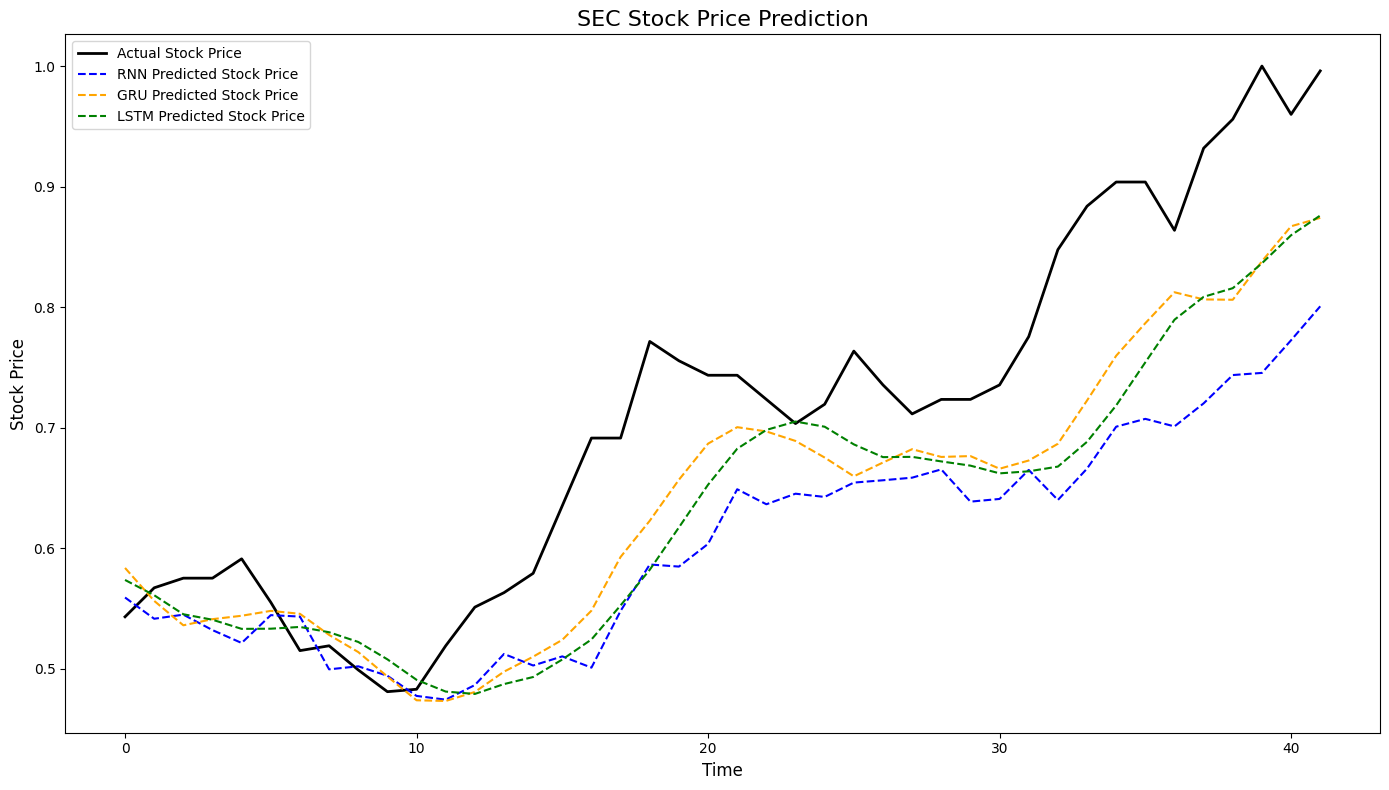

In [31]:
# 그래프 설정
plt.figure(figsize=(14, 8))

# 실제 주식 가격 (테스트 데이터의 실제 주식 가격)
plt.plot(test_y, label='Actual Stock Price', color='black', linestyle='-', linewidth=2)

# RNN 모델 예측값
plt.plot(predictions_RNN, label='RNN Predicted Stock Price', color='blue', linestyle='--')

# GRU 모델 예측값
plt.plot(predictions_GRU, label='GRU Predicted Stock Price', color='orange', linestyle='--')

# LSTM 모델 예측값
plt.plot(predictions_LSTM, label='LSTM Predicted Stock Price', color='green', linestyle='--')

# 그래프 제목과 레이블 설정
plt.title('SEC Stock Price Prediction', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Stock Price', fontsize=12)
plt.legend()

# 그래프 표시
plt.tight_layout()
plt.show()
